In [1]:
!which python
!python --version

/home/commander-data/Storage/users/mave/.venv/bin/python
Python 3.12.9


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.mixture import GaussianMixture

In [3]:
basepath = "/home/commander-data/Storage/users/mave/search_sequences_300_var"
datapath = '/'.join([basepath, "data/input/fastqs/X205SC23111498-Z01-F020/01.RawData"])
sspath = '/'.join([basepath, "data/input/search_sequences"])
plotpath = '/'.join([basepath, "data/output/plots"])

In [4]:
wide_mean = pd.read_csv("/home/commander-data/Storage/users/mave/search_sequences_300_var/data/output/wide_mean_new.tsv", sep = "\t")
wide_mean

,combined_var_id,cell_line,RPM_DNA,RPM_RNA,cprime_score,var_id,syn_var,start_combined,pangolin_gain_score_combined,pangolin_gain_pos_combined,...,clinvar_simple,combined_spliceai_gain_score,combined_spliceai_gain_pos,combined_spliceai_loss_score,combined_spliceai_loss_pos,combined_spliceai,spliceai_gain_score,spliceai_gain_pos_y,spliceai_loss_score,spliceai_loss_pos_y
0,chr17-31225098-G-A_chr17-31225106-A-G,K562,0.272886,0.528088,1.935194,chr17-31225098-G-A,chr17-31225106-A-G,31225098.0,0.10,43.0,...,conflicting,0.05,43.0,0.18,0.0,ACAGATAGG|NF1|+|0.05|0.18|0.00|0.07|43|0|-33|1...,0.10,43.0,0.04,0.0
1,chr17-31225098-G-A_chr17-31225106-A-G,KBM7,0.320949,0.235912,0.735044,chr17-31225098-G-A,chr17-31225106-A-G,31225098.0,0.10,43.0,...,conflicting,0.05,43.0,0.18,0.0,ACAGATAGG|NF1|+|0.05|0.18|0.00|0.07|43|0|-33|1...,0.10,43.0,0.04,0.0
2,chr17-31225098-G-A_chr17-31225109-T-C,K562,0.384005,0.872759,2.272781,chr17-31225098-G-A,chr17-31225109-T-C,31225098.0,0.07,43.0,...,conflicting,0.06,43.0,0.02,4.0,ACAGATAGAAGC|NF1|+|0.06|0.02|0.01|0.00|43|4|16...,0.10,43.0,0.04,0.0
3,chr17-31225098-G-A_chr17-31225109-T-C,KBM7,0.390721,0.613883,1.571155,chr17-31225098-G-A,chr17-31225109-T-C,31225098.0,0.07,43.0,...,conflicting,0.06,43.0,0.02,4.0,ACAGATAGAAGC|NF1|+|0.06|0.02|0.01|0.00|43|4|16...,0.10,43.0,0.04,0.0
4,chr17-31225098-G-T_chr17-31225106-A-G,K562,0.063999,0.220722,3.448860,chr17-31225098-G-T,chr17-31225106-A-G,31225098.0,0.18,43.0,...,unknown,0.14,43.0,0.38,0.0,TCAGATAGG|NF1|+|0.14|0.38|0.00|0.11|43|0|233|1...,0.22,43.0,0.24,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665,chr17-31336867-T-G_chr17-31336860-C-T,KBM7,0.196499,0.528887,2.691542,chr17-31336867-T-G,chr17-31336860-C-T,31336860.0,0.33,2.0,...,unknown,0.63,0.0,0.41,54.0,TTGGTCAG|NF1|+|0.02|0.00|0.63|0.41|-225|42|0|5...,0.75,-5.0,0.48,47.0
666,chr17-31336867-T-G_chr17-31336865-C-G,K562,0.055605,0.106962,1.923613,chr17-31336867-T-G,chr17-31336865-C-G,31336865.0,0.86,-3.0,...,unknown,0.99,-3.0,0.81,49.0,GAG|NF1|+|0.09|0.00|0.99|0.81|-169|37|-3|49|0....,0.75,-5.0,0.48,47.0
667,chr17-31336867-T-G_chr17-31336865-C-G,KBM7,0.060087,0.091401,1.521130,chr17-31336867-T-G,chr17-31336865-C-G,31336865.0,0.86,-3.0,...,unknown,0.99,-3.0,0.81,49.0,GAG|NF1|+|0.09|0.00|0.99|0.81|-169|37|-3|49|0....,0.75,-5.0,0.48,47.0
668,chr17-31336867-T-G_chr17-31336871-T-C,K562,0.123840,0.143552,1.159172,chr17-31336867-T-G,chr17-31336871-T-C,31336867.0,0.36,-5.0,...,unknown,0.66,-5.0,0.25,47.0,GTAAC|NF1|+|0.03|0.00|0.66|0.25|-232|35|-5|47|...,0.75,-5.0,0.48,47.0


In [ ]:
def get_gmm_data(cell_line, rpm_cutoff = 5, clip = 4, include_nonsense = True):
    if include_nonsense:
        mm_data = wide_mean[wide_mean["source"].isin(["ss_lib", "stop_syn_gained_lib", "stop_gained_lib", "ex27_lib_stop"]) &wide_mean["cell_line"].isin([cell_line]) &(wide_mean["RPM_DNA"] >= rpm_cutoff)].copy()
    else:
        mm_data = wide_mean[wide_mean["cell_line"].isin([cell_line]) & (wide_mean["RPM_DNA"] >= rpm_cutoff) & (wide_mean["source"].isin(["ss_lib", "stop_syn_gained_lib"])) & (wide_mean["consequence"] != "stop_gained")].copy()

    print(len(mm_data["var_id"].unique()))
    mm_data = mm_data[["var_id", "cprime_score", "clinvar_simple", "consequence", "pangolin_gain_bin"]].groupby(["var_id"], as_index=False).agg(cprime_score=("cprime_score", "mean"),clinvar_simple=("clinvar_simple", "first"),consequence=("consequence", "first"),pangolin_gain_bin=("pangolin_gain_bin", "first")) # take mean per intended edit
    print(len(mm_data))
    mm_data["cprime_score_norm"] = np.log(mm_data['cprime_score']).clip(lower=clip * -1, upper = clip)
    return mm_data

def plot_bars(data, title = "", xlab = "", ylab = "Number of variants", colors = None, save = None):
    ax = data.plot(
        kind = 'bar',
        stacked = True,
        color = colors,
        edgecolor = "black"
    )
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')
        label.set_rotation_mode('anchor')

    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()

    if save is not None:
        plt.savefig('/'.join(save), format = "pdf", bbox_inches="tight")

    plt.show()

In [6]:
outdir = "/home/commander-data/Storage/users/mave/search_sequences_300_var/data/output"

62
62


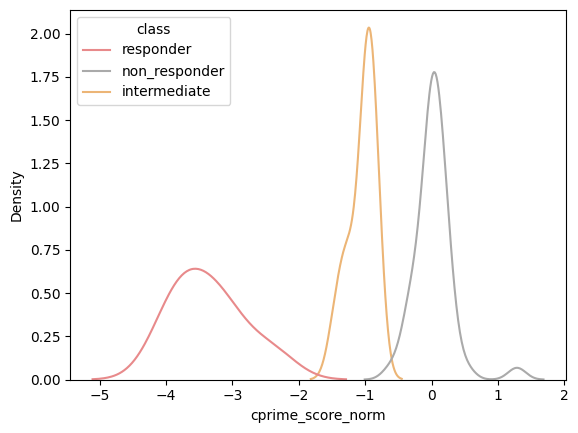

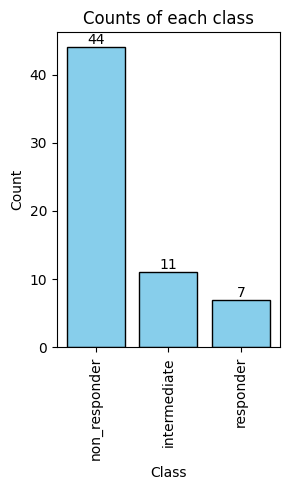

class
intermediate     11
non_responder    44
responder         7
dtype: int64


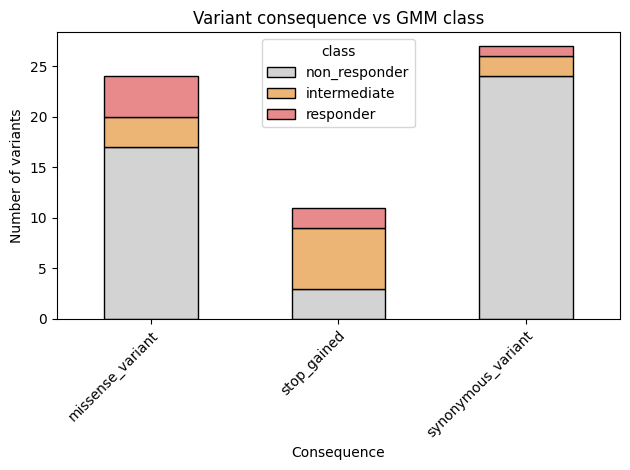

class
intermediate     11
non_responder    44
responder         7
dtype: int64


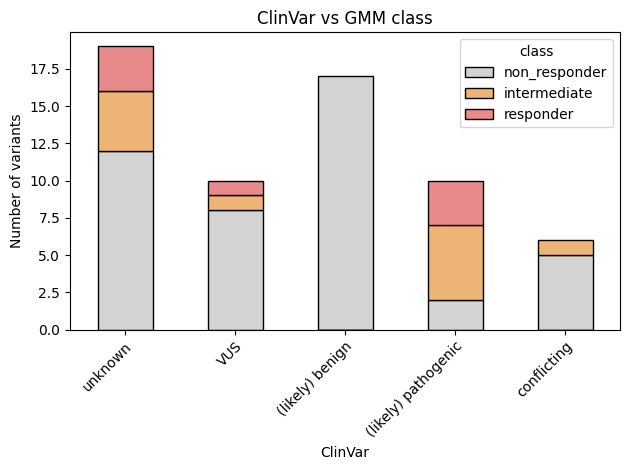

class
intermediate     11
non_responder    44
responder         7
dtype: int64


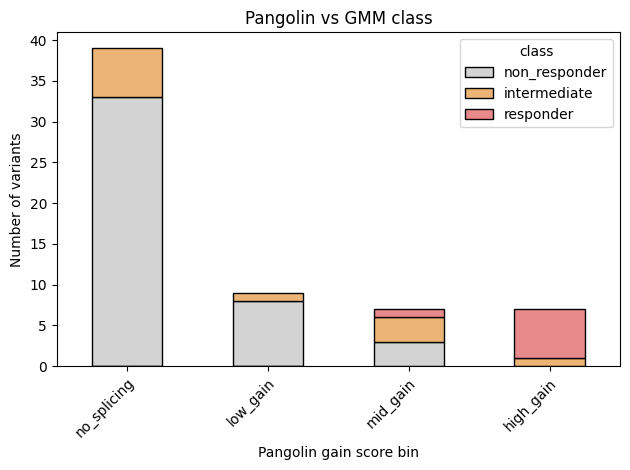

In [ ]:
# parameters
n_components = 3
seed = 0
clip = 4
cell_line = "K562"
include_nonsense = True

# start script
current_outdir = outdir + "/" + '_'.join([cell_line, "clip", str(clip), "components", str(n_components)])
Path(current_outdir).mkdir(parents=True, exist_ok=True)


mm_data = get_gmm_data(cell_line = cell_line, clip = clip, include_nonsense = include_nonsense)
x = mm_data["cprime_score_norm"].to_numpy().reshape(-1, 1)


gmm = GaussianMixture(n_components=n_components, random_state=0)
gmm.fit(x)

probs = gmm.predict_proba(x)
means = gmm.means_.flatten()
order = np.argsort(means)

if n_components == 3:
    depleted = order[0]
    intermediate = order[1]
    neutral = order[2]

    label_map = {
        depleted: "responder",
        intermediate: "intermediate",
        neutral: "non_responder",
    }

    the_order = ['non_responder', 'intermediate', 'responder']
elif n_components == 2:
    depleted = order[0]
    neutral = order[1]

    df2 = mm_data.copy()
    df2["max_prob"] = probs.max(axis=1)
    df2["component"] = probs.argmax(axis=1)

    label_map = {
        depleted: "responder",
        neutral: "non_responder",
    }

    the_order = ['non_responder', 'responder']

df2 = mm_data.copy()
df2["max_prob"] = probs.max(axis=1)
df2["component"] = probs.argmax(axis=1)
df2["class"] = df2["component"].map(label_map)

# there is only one variant which is missing annotation from the exon 27 copied nonsense variants.
# we can fill that manually
df2.loc[df2["var_id"] == "chr17-31233005-T-G", "consequence"] = "stop_gained"
df2.loc[df2["var_id"] == "chr17-31233005-T-G", "pangolin_gain_bin"] = "no_splicing"

# write some stats
with open(current_outdir + "/numbers.txt", "w") as f:
    f.write("Means:" + str(means) + "\n")
    f.write("Weights:" + str(gmm.weights_) + "\n")
    f.write("BIC:" + str(gmm.bic(x)) + "\n")
    f.write("Number of variants:\n")
    f.write(str(df2["class"].value_counts()))


# plot distributions
sns.kdeplot(
    data=df2,
    x='cprime_score_norm',
    hue='class',
    common_norm=False,
    palette = {
        "responder": "#E88A8B",
        "intermediate": "#ECB576",
        "non_responder": "#AAAAAA",
    }
)
plt.savefig(
    '/'.join([current_outdir, cell_line + "_GMM.pdf"]),
    format = "pdf",
    bbox_inches="tight"
)

# save data to file
df2.to_csv(current_outdir + "/" + cell_line + "_GMM_classification.tsv", sep = "\t", index = False)


# plot number of variants that go into the gmm
# Count how many times each class appears
class_counts = df2["class"].value_counts()

plt.figure(figsize=(3, 5))
bars = plt.bar(
    class_counts.index,
    class_counts.values,
    color = "skyblue",
    edgecolor = "black"
)

# Add count labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha = "center",
        va="bottom"
    )

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Counts of each class")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    '/'.join([current_outdir, cell_line + "_number_of_responders.pdf"]),
    format = "pdf",
    bbox_inches="tight"
)

plt.show()



# colors for later plotting
color_map = {
    "responder": "#E88A8B",
    "intermediate": "#ECB576",
    "non_responder": "lightgray",
}

# plot number of variants by consequence and gmm class
counts = df2.groupby(['consequence', 'class']).size().unstack(fill_value=0)
print(counts.sum())

# sort stacked bars
counts = counts[the_order]

# define colors
categories = list(counts.columns)
colors = [color_map[c] for c in categories]

# the actual plot
plot_bars(
    counts, 
    title = "Variant consequence vs GMM class", xlab = "Consequence", 
    colors = colors,
    save = [current_outdir, cell_line + "_GMM_vs_consequence.pdf"],
)


counts = df2.groupby(['clinvar_simple', 'class']).size().unstack(fill_value=0)
counts.index = [x if x not in ["benign", "pathogenic"] else "(likely) " + x for x in counts.index]
print(counts.sum())

# sort x axis and stacked bars
counts = counts[the_order]
counts = counts.reindex(["unknown", "VUS", "(likely) benign", "(likely) pathogenic", "conflicting"])

# define colors
categories = list(counts.columns)
colors = [color_map[c] for c in categories]

# the actual plot
plot_bars(
    counts, 
    title = "ClinVar vs GMM class", xlab = "ClinVar", 
    colors = colors,
    save = [current_outdir, cell_line + "_GMM_vs_clinvar.pdf"],
)


# plot number of variants by pangolin group and gmm class
counts = df2.groupby(['pangolin_gain_bin', 'class']).size().unstack(fill_value=0)
print(counts.sum())

# sort x axis and stacked bars
counts = counts[the_order]
counts = counts.reindex(["no_splicing", "low_gain", "mid_gain", "high_gain"])

# define colors
categories = list(counts.columns)
colors = [color_map[c] for c in categories]

# the actual plot
plot_bars(
    counts, 
    title = "Pangolin vs GMM class", xlab = "Pangolin gain score bin", 
    colors = colors,
    save = [current_outdir, cell_line + "_GMM_vs_pangolin.pdf"],
)

62
62
70
70


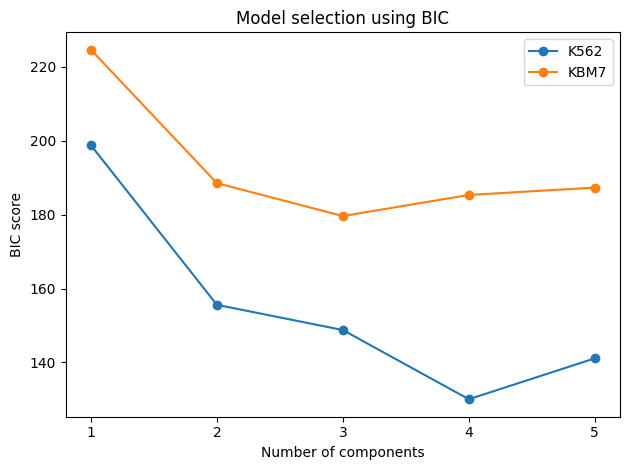

In [12]:


# figure to see all bic values
all_bics = {}
for cell_line in ["K562", "KBM7"]:
    mm_data = get_gmm_data(cell_line = cell_line, clip = clip, include_nonsense = include_nonsense)
    x = mm_data["cprime_score_norm"].to_numpy().reshape(-1, 1)

    models = {}
    bics = []
    for k in [1, 2, 3, 4, 5]:
        gmm = GaussianMixture(n_components=k, random_state=0)
        gmm.fit(x)
        models[k] = gmm
        bics.append(gmm.bic(x))
    all_bics[cell_line] = bics




components = [1, 2, 3, 4, 5]

plt.figure()

plt.plot(components, all_bics["K562"], marker='o', label='K562')
plt.plot(components, all_bics["KBM7"], marker='o', label='KBM7')

plt.xlabel('Number of components')
plt.ylabel('BIC score')
plt.title('Model selection using BIC')
plt.xticks(components)
plt.legend()

plt.tight_layout()

plt.savefig(
    '/'.join([plotpath, "gmm_model_bic.pdf"]),
    format = "pdf",
    bbox_inches="tight"
)

plt.show()